# **Análisis descriptivo del crecimiento del Producto Interno Bruto mexicano**
  
El Producto Interno Bruto (PIB) es el indicador de la producción total de los bienes y servicios finales que produce un país en un periodo determinado. Su utilidad radica en que sirve para medir el comportamiento global de una economía.

El análisis busca responder a las siguientes preguntas:
1. ¿Cómo ha evolucionado el PIB?
2. ¿Cuánto ha crecido el PIB en el último trimestre registrado?
3. ¿Cómo ha sido el crecimiento del PIB en los últimos cinco años?

En cuanto a la serie desestacionalizada se busca:
1. ¿Cómo se compara la serie original con la serie desestacionalizada?
2. ¿Cómo se comparan los crecimientos anuales?
3. ¿Cuánto ha crecido el PIB en su último trimestre respecto al trimestre anterior? 
4. ¿Cómo ha sido el crecimiento del PIB de los últimos 10 trimestres registrados?

El presente análisis tiene un carácter descriptivo. Su objetivo es caracterizar la evolución del PIB a partir de las series publicadas por INEGI, mediante visualizaciones y cálculo de tasas de crecimiento. No se busca establecer relaciones causales, construir modelos econométricos ni generar pronósticos.

# **Fuente**

Para el análisis se utilizan dos series:

- **Serie original:**
    - Fuente: INEGI, Banco de Información Económica (BIE). PIB trimestral a precios de 2018, millones de pesos.

- **Serie desestacionalizada:**
    - Fuente: INEGI, Banco de Información Económica (BIE). PIB trimestral a precios de 2018, serie desestacionalizada, millones de pesos.

Ver `README.md` para el detalle completo de la consulta y notas metodológicas.

In [1]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np

In [2]:
# Cargar datos

pib_normal = pd.read_csv('../data/pib-precios-2018.csv')
pib_desest = pd.read_csv('../data/pib-precios-2018-desestacionalizada.csv')

# Mostrar datos serie original

pib_normal

,Periodos,PIB
0,1980/01,10401367.61
1,1980/02,10342350.00
2,1980/03,10392733.01
3,1980/04,10927666.35
4,1981/01,11345848.49
...,...,...
181,2025/02,25618678.77
182,2025/03,25422850.19
183,2025/04,26135644.70
184,2026/01,24963384.14


## **Serie original**

### **1. ¿Cómo ha evolucionado el PIB?**

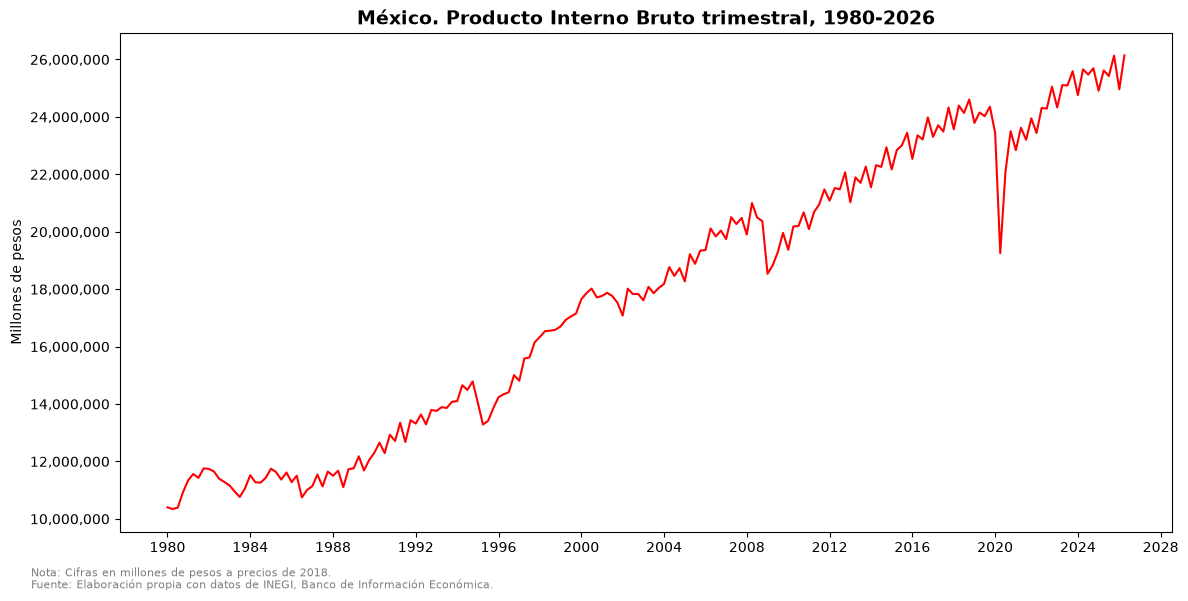

In [3]:
# Gráfica de la evolución del PIB

# 1. Preparación y conversión de los datos

pib_normal['fecha'] = pd.PeriodIndex(pib_normal['Periodos'].str.replace(r'(\d{4})/0?(\d)', r'\1Q\2', regex=True), freq='Q').to_timestamp()

# 2. Creación de la figura y gráfica

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pib_normal['fecha'], pib_normal['PIB'], color='red')

ax.set_title('México. Producto Interno Bruto trimestral, 1980-2026', fontsize=14, fontweight='bold')

# 3. Configuración de los ejes

# 3.1. Configuración del eje X

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3.2. Configuración del eje Y

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
ax.set_ylabel('Millones de pesos')

# 4. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Nota: Cifras en millones de pesos a precios de 2018.', fontsize=8, color='grey', ha='left')
plt.tight_layout(rect=[0, 0.04, 1, 1])

# 5. Guardar gráfica en directorio figures

plt.savefig('../figures/grafica_01_evolucion_pib.png', dpi=150, bbox_inches='tight')

# 6. Mostrar gráfica

plt.show()

La serie original del PIB muestra una evolución generalmente creciente a lo largo del periodo analizado, con fluctuaciones al alza y a la baja entre trimestres. En general, se observa una tendencia ascendente en el largo plazo.

Asimismo, se identifican cinco contracciones a simple vista en la gráfica. Cada periodo va del pico al valle: el pico es el trimestre de mayor PIB antes de la caída y el valle es el de menor PIB del episodio. La caída ocupa los trimestres entre ambos. Los periodos se delimitan visualmente, sin una definición formal de recesión, y el análisis describe cuándo cae el PIB, no por qué. El contexto de cada periodo proviene de notas periodísticas (Expansión, 2023; Sandoval, 2024) y se incluye solo como referencia: no es un resultado de este análisis.

1. **4T-1981 a 3T-1983, crisis de la deuda externa.** Según Expansión (2023), en 1982 cayeron los precios y la demanda del petróleo, y México recurrió a préstamos externos de corto plazo para frenar la fuga de capitales y cubrir el servicio de la deuda. Ese año el crecimiento del PIB fue cercano a cero, las reservas internacionales de Banxico cayeron a niveles muy bajos, el peso se devaluó y se nacionalizó la banca.
2. **4T-1994 a 2T-1995, "Efecto Tequila".** Según Expansión (2023), buena parte del capital recibido era volátil y salió cuando subieron las tasas de interés en EE. UU. Esto, junto con el tipo de cambio semifijo y el uso de reservas, llevó a la devaluación del peso en 1995 y a una crisis bancaria.
3. **2T-2001 a 1T-2002, crisis "dot com".** Según Sandoval (2024), la recesión tuvo origen externo: la caída de la burbuja tecnológica en EE. UU. se transmitió a México por la mayor integración comercial tras el TLCAN. La fuente ubica el inicio en octubre de 2000, antes del 2T-2001 que se observa en la gráfica.
4. **2T-2008 a 1T-2009, crisis financiera global.** Según Sandoval (2024), se originó en EE. UU. por la insostenibilidad del mercado de hipotecas *subprime*, que derivó en una crisis inmobiliaria y financiera con la caída de bancos de inversión y aseguradoras.
5. **4T-2019 a 2T-2020, caída previa y pandemia de COVID-19.** Según Sandoval (2024), la recesión tuvo dos etapas. La primera, de junio a diciembre de 2019, se caracterizó por la contracción de la inversión privada (3.3%) y pública (13.2%). La segunda se explica por la pandemia, con impacto más severo desde febrero de 2020.

Tras esta última contracción y su rápida recuperación, el PIB mexicano regresa en 2022 a niveles similares a los prepandemia, retomando su tendencia ascendente.


### **2. Crecimiento interanual del último trimestre registrado (2T-2026)**

Se compara el mismo trimestre de años consecutivos (en lugar del trimestre inmediato anterior) para eliminar el efecto estacional, ya que la serie original no está desestacionalizada. Esta comparación no elimina los efectos de calendario, como el cambio de fecha de la Semana Santa entre marzo y abril.

In [4]:
# Crecimiento interanual 2T-2026 vs 2T-2025

# 1. Filtrar los trimestres correspondientes

pib_inter = pib_normal.query('Periodos in ["2025/02", "2026/02"]')

# 2. Crear la columna "Crecimiento_%" y calcular el crecimiento interanual

pib_inter['Crecimiento_%'] = pib_inter['PIB'].pct_change().round(3) * 100

# 3. Mostrar los datos

pib_inter[['Periodos', 'PIB', 'Crecimiento_%']]

,Periodos,PIB,Crecimiento_%
181,2025/02,25618678.77,NaN
185,2026/02,26144132.44,2.1


El PIB registra un crecimiento interanual de 2.1% en el segundo trimestre de 2026, respecto al segundo trimestre de 2025.

### **3. Crecimiento del PIB en los últimos cinco años (2021-2025)**

Para analizar el crecimiento del PIB en los últimos cinco años, se considera el periodo 2021-2025. El PIB anual se calcula mediante el promedio simple de los cuatro trimestres que componen cada año, metodología que retoma el libro *Lo que indican los indicadores* (Heath, 2012).

Para obtener la variación de cada uno de los cinco años, el cálculo parte de 2020. Es decir, el crecimiento de 2021 se calcula respecto a 2020, el de 2022 respecto a 2021, y así sucesivamente hasta 2025. De esta forma, aunque la serie abarca datos desde 2020, los valores de crecimiento presentados corresponden únicamente al periodo 2021-2025.

Cabe señalar que, aunque el texto habla de "crecimiento", la gráfica etiqueta el eje Y como **variación porcentual anual (%)**, ya que es la forma estándar de expresar la tasa de cambio del PIB respecto al año anterior.

In [5]:
# Crecimiento del PIB en los últimos cinco años (2021-2025)

# 1. Función para calcular el PIB anual mediante el promedio de los trimestres

def calcular_pib_anual(año):
    
    # 1.1. Filtrar los trimestres que pertenecen al año indicado
    
    pib_filtro = pib_normal[pib_normal['Periodos'].str.startswith(año)]
    
    # 1.2. Calcular el promedio del PIB trimestral para ese año
    
    pib_promedio = pib_filtro['PIB'].mean()
    
    return pib_promedio

# 2. Ejecutar la función a cada año

# 2.1. Definir las listas de trabajo

lista_años = ["2020", "2021", "2022", "2023", "2024", "2025"]   # Años a analizar
resultado_funcion = []   # Lista vacía donde se guarda el PIB anual de cada año

# 2.2. Recorrer la lista de años y almacenar el PIB promedio de cada uno

for año in lista_años:
    resultado_funcion.append(calcular_pib_anual(año))
    
# 3. Crear un nuevo DataFrame con los años y sus respectivos valores de PIB anual

pib_anual = pd.DataFrame({'Año': lista_años, 'PIB': resultado_funcion})
pib_anual['PIB'] = pib_anual['PIB'].round(2)

# 4. Calcular el crecimiento anual del PIB en la columna "Crecimiento_%"

pib_anual['Crecimiento_%'] = (pib_anual['PIB'].pct_change() * 100).round(1)

# 5. Mostrar los datos

pib_anual

,Año,PIB,Crecimiento_%
0,2020,22069934.76,NaN
1,2021,23404831.12,6.0
2,2022,24273093.50,3.7
3,2023,25031031.64,3.1
4,2024,25396468.50,1.5
5,2025,25522695.98,0.5


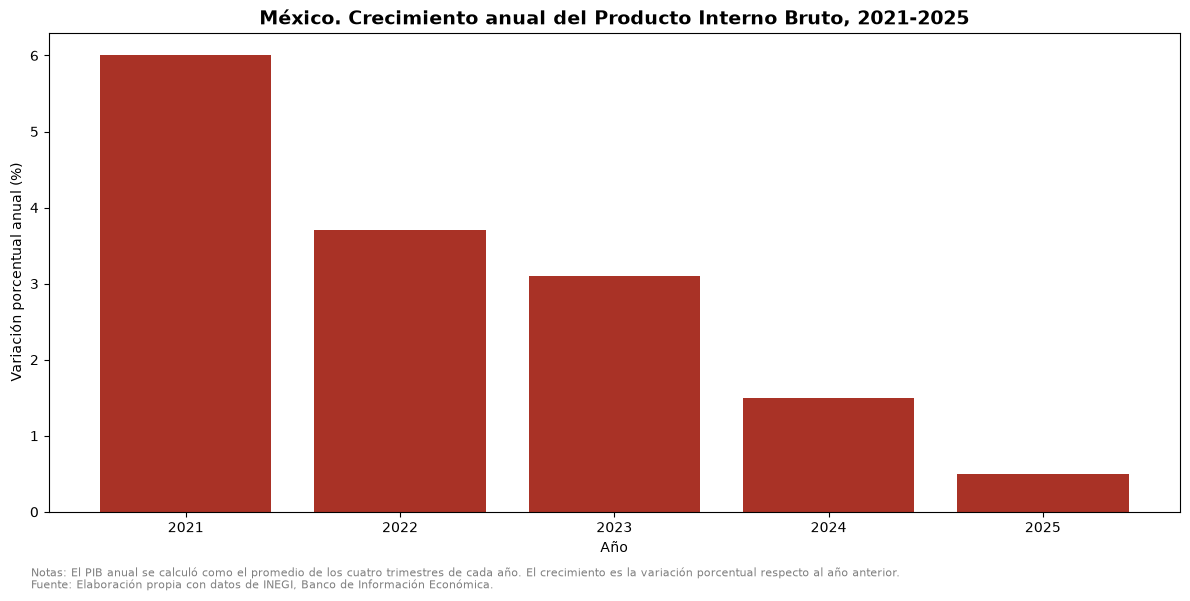

In [6]:
# Gráfica del crecimiento anual del PIB

# 1. Crear la figura y la gráfica de barras

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(pib_anual['Año'], pib_anual['Crecimiento_%'], color='#A93226')

ax.set_title('México. Crecimiento anual del Producto Interno Bruto, 2021-2025', fontsize=14, fontweight='bold')

# 2. Configurar los ejes

# 2.1. Eje X

ax.set_xlabel('Año')

# 2.2. Eje Y

ax.set_ylabel('Variación porcentual anual (%)')

# 3. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Notas: El PIB anual se calculó como el promedio de los cuatro trimestres de cada año. El crecimiento es la variación porcentual respecto al año anterior.', fontsize=8, color='grey', ha='left')
plt.tight_layout(rect=[0, 0.04, 1, 1])

# 4. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_02_crecimiento_pib_anual.png', dpi=150, bbox_inches='tight')

# 5. Mostrar gráfica

plt.show()

El crecimiento del PIB mexicano se desacelera año con año durante el periodo analizado (2021-2025). El periodo muestra tres etapas: un fuerte repunte en 2021, un crecimiento moderado en 2022 y 2023, y un crecimiento bajo en 2024 y 2025.

El año con mayor crecimiento es 2021, cuando el PIB aumenta 6.0% con respecto a 2020. Esta tasa elevada refleja en parte la base baja de 2020: como el PIB cae con fuerza ese año, cualquier recuperación se traduce en una tasa alta.

El año con menor crecimiento es 2025, cuando el PIB aumenta 0.5% con respecto a 2024, un nivel cercano al estancamiento.

En resumen, tras el repunte de 2021 (6.0%), las tasas de 2022 (3.7%) y 2023 (3.1%) son moderadas, y las de 2024 (1.5%) y 2025 (0.5%) caen a niveles bajos. Aunque el PIB no se contrae en ninguno de los años analizados, el ritmo de expansión se debilita cada año.

## **Serie desestacionalizada**

Para analizar el comportamiento del PIB sin la distorsión de patrones recurrentes, se recurre a la serie desestacionalizada. A esta serie se le eliminan las variaciones estacionales y los efectos de calendario, con el fin de facilitar la comparación entre periodos. Las variaciones estacionales son patrones que se repiten cada año, como el aumento de la actividad económica en diciembre. Los efectos de calendario dependen de las fechas, como la Semana Santa, que cae en marzo o abril según el año, o el número de días hábiles de cada trimestre.

Esta serie permite comparar cada trimestre contra su inmediato anterior (t vs. t-1), algo que no es válido hacer con la serie original sin desestacionalizar.

*Nota: los datos de 1993 a 2026 son preliminares. Ver README para más detalle.*

### **1. ¿Cómo ha evolucionado el PIB? (comparación con la serie original)**

Se compara la serie desestacionalizada contra la serie original para identificar qué patrones se confirman y qué cambia al remover el componente estacional.

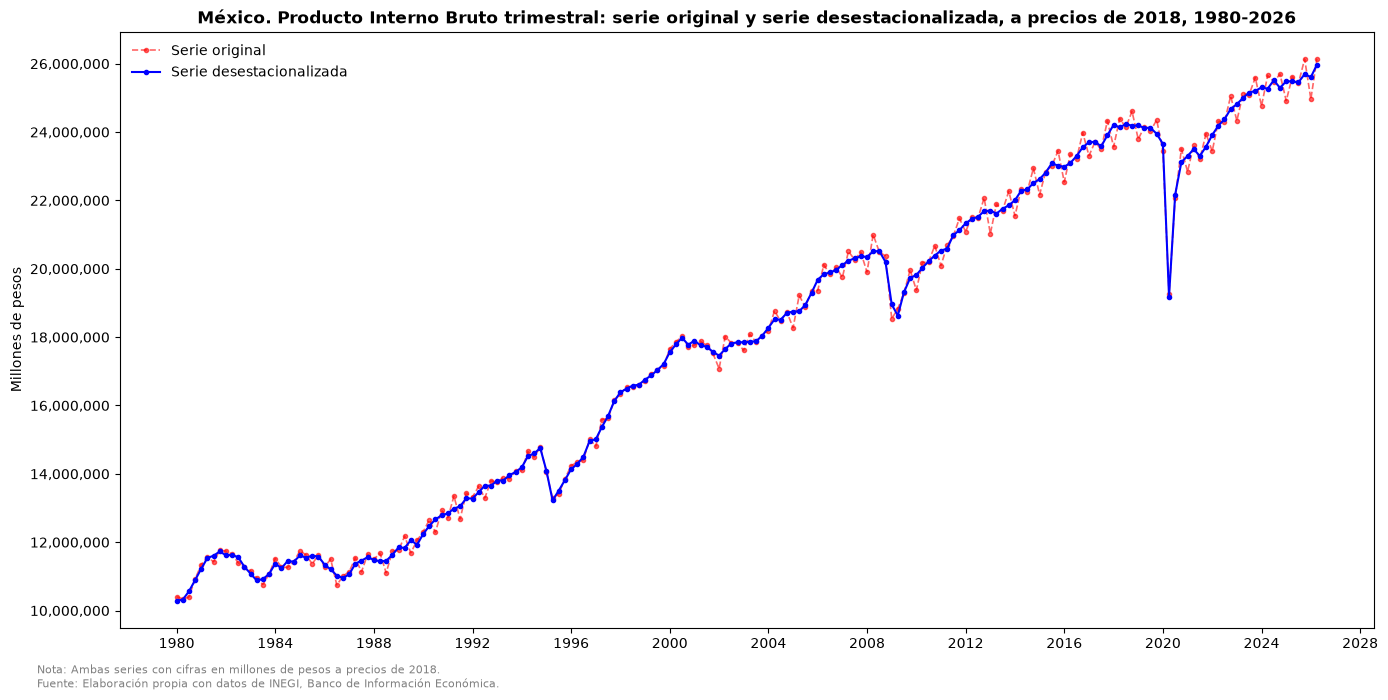

In [7]:
# Gráfica de la evolución del PIB (serie original y serie desestacionalizada)

# 1. Preparación y conversión de los datos desestacionalizados

pib_desest['fecha'] = pd.PeriodIndex(pib_desest['Periodos'].str.replace(r'(\d{4})/0?(\d)', r'\1Q\2', regex=True), freq='Q').to_timestamp()

# 2. Crear la figura y la gráfica

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(pib_normal['fecha'], pib_normal['PIB'], linestyle='--', color='red', marker='.', linewidth=1.2, alpha=0.6, zorder=1, label='Serie original')
ax.plot(pib_desest['fecha'], pib_desest['PIB'], color='blue', marker='.', linewidth=1.5, zorder=2, label='Serie desestacionalizada')

ax.set_title('México. Producto Interno Bruto trimestral: serie original y serie desestacionalizada, a precios de 2018, 1980-2026', fontsize=12, fontweight='bold')

# 3. Configurar los ejes

# 3.1. Eje X

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3.2. Eje Y

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
ax.set_ylabel('Millones de pesos')

# 4. Agregar leyenda

ax.legend(loc='upper left', frameon=False, fontsize=10)

# 5. Agregar fuente y nota metodológica

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Nota: Ambas series con cifras en millones de pesos a precios de 2018.', fontsize=8, color='grey', ha='left')

plt.tight_layout(rect=[0, 0.04, 1, 1])

# 6. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_03_comparacion_series.png', dpi=150, bbox_inches='tight')

# 7. Mostrar gráfica

plt.show()

La serie desestacionalizada confirma las cinco contracciones identificadas en la serie original, lo cual es lo esperado: la desestacionalización elimina el componente estacional, no los efectos de las crisis. Igual que en la serie original, los periodos se delimitan visualmente, sin una definición formal de recesión. El contexto de cada episodio es el mismo que se resume arriba.

Los periodos en la serie desestacionalizada son:
1. **Crisis de la deuda externa:** 2T-1982 a 2T-1983.
2. **"Efecto Tequila":** 4T-1994 a 2T-1995.
3. **Crisis "dot com":** 1T-2001 a 1T-2002.
4. **Crisis financiera global:** 3T-2008 a 2T-2009.
5. **Caída previa y pandemia de COVID-19:** 3T-2019 a 2T-2020.

Las caídas son las mismas, pero los periodos difieren hasta dos trimestres respecto a la serie original, salvo el "Efecto Tequila", que coincide en ambas. Estas diferencias pueden deberse a que las oscilaciones estacionales desplazan el trimestre en que se ubican el máximo y el mínimo de cada caída, y a que los periodos se delimitan a simple vista. Por ejemplo, en la crisis "dot com" la serie original ubica el inicio en el 2T-2001 y la desestacionalizada en el 1T-2001, y el final coincide (1T-2002). En la crisis financiera global ocurre lo contrario: la serie original abarca del 2T-2008 al 1T-2009 y la desestacionalizada del 3T-2008 al 2T-2009.

Además, en la serie desestacionalizada se delimita una contracción adicional, con pico en el 3T-1985 y valle en el 4T-1986, con cinco trimestres consecutivos de caída. En la serie original también se aprecia un descenso en esos años, pero las oscilaciones estacionales dificultan identificar su inicio y su fin con la misma claridad.

Según Casillas (2022), en agosto de 1985 el FMI suspendió un desembolso de crédito; semanas después, los sismos de septiembre dañaron la infraestructura de la Ciudad de México. En esos meses el precio del petróleo pasó de 29.08 dólares por barril en septiembre de 1985 a 13.26 en febrero de 1986 (-54.4%). El autor señala también que el peso se devaluó 200% y que la inflación anual superó 100% a finales de 1986.

La serie desestacionalizada también muestra un estancamiento en 2018 y 2019, con pico en el 3T-2019 y caída posterior. Esto coincide con la primera etapa de la recesión de 2020 que describe Sandoval (2024), previa a la pandemia, sobre la cual la pandemia provoca un descenso abrupto.

En conclusión, la serie original sirve para conocer el nivel observado del PIB, pero sus oscilaciones estacionales dificultan identificar con precisión el inicio y el fin de las caídas. La serie desestacionalizada es más adecuada para delimitar los periodos de contracción y recuperación, y para analizar la evolución de largo plazo del PIB mexicano.

### **2. ¿Cómo se comparan los crecimientos anuales?**

Se obtiene el PIB anual de la serie desestacionalizada con el mismo método usado en la serie original (promedio simple de los cuatro trimestres) y se comparan los crecimientos anuales de ambas series. Dado que al promediar los cuatro trimestres el efecto estacional tiende a cancelarse, se espera que los resultados sean similares.

In [8]:
# Comparación de los crecimientos anuales: serie original vs serie desestacionalizada (2021-2025)

# 1. Función para calcular el PIB anual desestacionalizado mediante el promedio de los trimestres

def calcular_pib_anual_desest(año):
    
    # 1.1. Filtrar los trimestres que pertenecen al año indicado
    
    pib_filtro = pib_desest[pib_desest['Periodos'].str.startswith(año)]
    
    # 1.2. Calcular el promedio del PIB trimestral para ese año
    
    pib_promedio = pib_filtro['PIB'].mean()
    
    return pib_promedio

# 2. Ejecutar la función a cada año

# 2.1. Definir la lista vacía donde se guarda el PIB anual desestacionalizado de cada año

resultado_funcion_desest = [] 

# 2.2. Recorrer la lista de años y almacenar el PIB promedio de cada uno

for año in lista_años:
    resultado_funcion_desest.append(calcular_pib_anual_desest(año))
    
# 3. Crear un nuevo DataFrame con los años y sus respectivos valores de PIB anual

pib_anual_desest = pd.DataFrame({'Año': lista_años, 'PIB_desest': resultado_funcion_desest})
pib_anual_desest['PIB_desest'] = pib_anual_desest['PIB_desest'].round(2)

# 4. Calcular el crecimiento anual del PIB en la columna "Crecimiento_desest_%"

pib_anual_desest['Crecimiento_desest_%'] = (pib_anual_desest['PIB_desest'].pct_change() * 100).round(1)

# 5. Copiar la columna "Crecimiento_%" de pib_anual como "Crecimiento_original_%"
# (.values evita desalineamientos de índice; ambos DataFrames tienen los mismos años en el mismo orden)

pib_anual_desest['Crecimiento_original_%'] = pib_anual['Crecimiento_%'].values

# 6. Calcular la diferencia entre ambos crecimientos (en puntos porcentuales)

pib_anual_desest['Diferencia_pp'] = (pib_anual_desest['Crecimiento_desest_%'] - pib_anual_desest['Crecimiento_original_%']).round(1)

# 7. Mostrar los datos

pib_anual_desest[['Año', 'Crecimiento_original_%', 'Crecimiento_desest_%', 'Diferencia_pp']]

,Año,Crecimiento_original_%,Crecimiento_desest_%,Diferencia_pp
0,2020,NaN,NaN,NaN
1,2021,6.0,6.3,0.3
2,2022,3.7,3.7,0.0
3,2023,3.1,3.1,0.0
4,2024,1.5,1.2,-0.3
5,2025,0.5,0.7,0.2


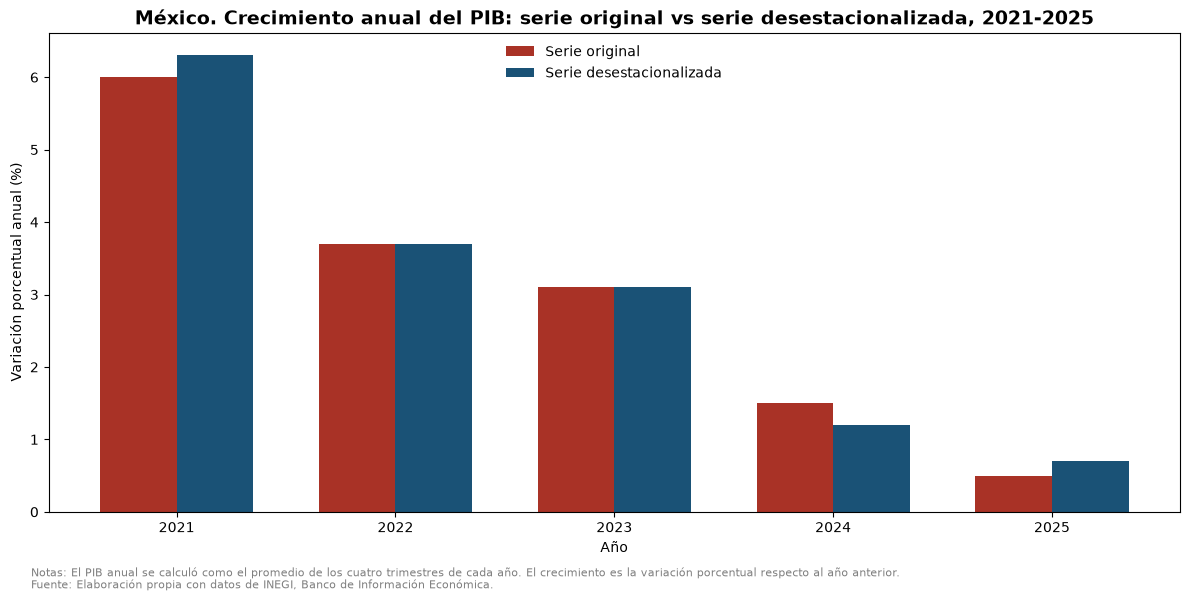

In [9]:
# Gráfica comparación del crecimiento anual del PIB: serie original vs serie desestacionalizada

# 1. Quitar el año base (2020), ya que no tiene valor

comparacion_barras = pib_anual_desest.dropna(subset=['Crecimiento_desest_%'])

# 2. Definir posiciones numéricas y ancho de las barras

posiciones = np.arange(len(comparacion_barras))
ancho = 0.35

# 3. Crear la figura y la gráfica de barras

fig, ax= plt.subplots(figsize=(12, 6))

ax.bar(posiciones - ancho/2, comparacion_barras['Crecimiento_original_%'], color='#A93226', width=ancho, label='Serie original')
ax.bar(posiciones + ancho/2, comparacion_barras['Crecimiento_desest_%'], color='#1A5276', width=ancho, label='Serie desestacionalizada')

ax.set_title('México. Crecimiento anual del PIB: serie original vs serie desestacionalizada, 2021-2025', fontsize=14, fontweight='bold')

# 4. Configurar los ejes

# 4.1. Eje X

ax.set_xlabel('Año')

# 4.2. Eje Y

ax.set_ylabel('Variación porcentual anual (%)')

# 5. Colocar los años como etiquetas del eje X

ax.set_xticks(posiciones)
ax.set_xticklabels(comparacion_barras['Año'])

# 6. Agregar leyenda

ax.legend(loc='upper center', frameon=False, fontsize=10)

# 7. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Notas: El PIB anual se calculó como el promedio de los cuatro trimestres de cada año. El crecimiento es la variación porcentual respecto al año anterior.', fontsize=8, color='grey', ha='left')

plt.tight_layout(rect=[0, 0.04, 1, 1])

# 8. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_04_comparacion_crecimiento_anual_series.png', dpi=150, bbox_inches='tight')

# 9. Mostrar gráfica

plt.show()

Los crecimientos anuales de ambas series son similares y muestran la misma lectura: un fuerte repunte en 2021, un crecimiento moderado en 2022 y 2023, y un crecimiento bajo en 2024 y 2025. En ambas series el ritmo de expansión se desacelera cada año.

Las tasas coinciden en 2022 (3.7%) y 2023 (3.1%). En los otros tres años la diferencia no supera 0.3 puntos porcentuales: en 2021 la serie desestacionalizada crece 6.3% frente a 6.0% de la original (0.3 p.p.), en 2024 crece 1.2% frente a 1.5% (-0.3 p.p.) y en 2025 crece 0.7% frente a 0.5% (0.2 p.p.).

Que las tasas sean similares es lo esperado: al promediar los cuatro trimestres de cada año, el efecto estacional tiende a cancelarse. Las diferencias restantes pueden deberse a los efectos de calendario que ajusta la serie desestacionalizada y a las revisiones de INEGI; este análisis no permite separar una causa de la otra. En 2024, la diferencia de 0.3 p.p. equivale a una quinta parte de la tasa de la serie original (1.5%), pero no altera la conclusión: el crecimiento se desacelera de forma continua, desde el repunte de 2021 hasta el crecimiento más bajo en 2025.

### **3. Crecimiento del último trimestre respecto a su inmediato anterior (2T-2026 vs 1T-2026)**

A diferencia de la serie original, en la serie desestacionalizada sí es válido comparar un trimestre contra el inmediato anterior, ya que el componente estacional ya fue removido.

In [10]:
# Crecimiento del último trimestre con respecto al inmediato anterior (2T-2026 vs 1T-2026)

# 1. Filtrar para obtener únicamente los últimos dos trimestres

ultimos_trimestres = pib_desest.query('Periodos in ["2026/01", "2026/02"]')

# 2. Calcular el crecimiento trimestral en la columna "Crecimiento_trimestral"

ultimos_trimestres['Crecimiento_trimestral'] = (ultimos_trimestres['PIB'].pct_change() * 100).round(1)

# 3. Mostrar los resultados

ultimos_trimestres[['Periodos', 'PIB', 'Crecimiento_trimestral']]

,Periodos,PIB,Crecimiento_trimestral
184,2026/01,25606452.75,NaN
185,2026/02,25971192.58,1.4


En el segundo trimestre de 2026, el PIB desestacionalizado registra un crecimiento de 1.4% con respecto al trimestre anterior. Este resultado indica una expansión de la actividad económica en el trimestre.

### **4. Crecimiento trimestral en los últimos 10 trimestres (1T-2024 a 2T-2026)**

In [11]:
# Crecimiento de los último 10 trimestres (1T-2024 a 2T-2026)

# 1. Calcular el crecimiento trimestral en la columna "Crecimiento_trimestral" para toda la serie

pib_desest['Crecimiento_trimestral'] = pib_desest['PIB'].pct_change() * 100

# 2. Filtrar para obtener los últimos 10 trimestres

trimestres = pib_desest[pib_desest['Periodos'].str.startswith(("2024", "2025", "2026"))]

# 3. Redondear y eliminar el signo negativo del cero

trimestres['Crecimiento_trimestral'] = trimestres['Crecimiento_trimestral'].round(1) + 0.0

# 4. Mostrar los resultados

trimestres[['Periodos', 'PIB', 'Crecimiento_trimestral']]

,Periodos,PIB,Crecimiento_trimestral
176,2024/01,25306022.44,0.4
177,2024/02,25266256.67,-0.2
178,2024/03,25515285.34,1.0
179,2024/04,25290826.80,-0.9
180,2025/01,25486696.26,0.8
181,2025/02,25480578.99,0.0
182,2025/03,25453873.70,-0.1
183,2025/04,25694485.95,0.9
184,2026/01,25606452.75,-0.3
185,2026/02,25971192.58,1.4


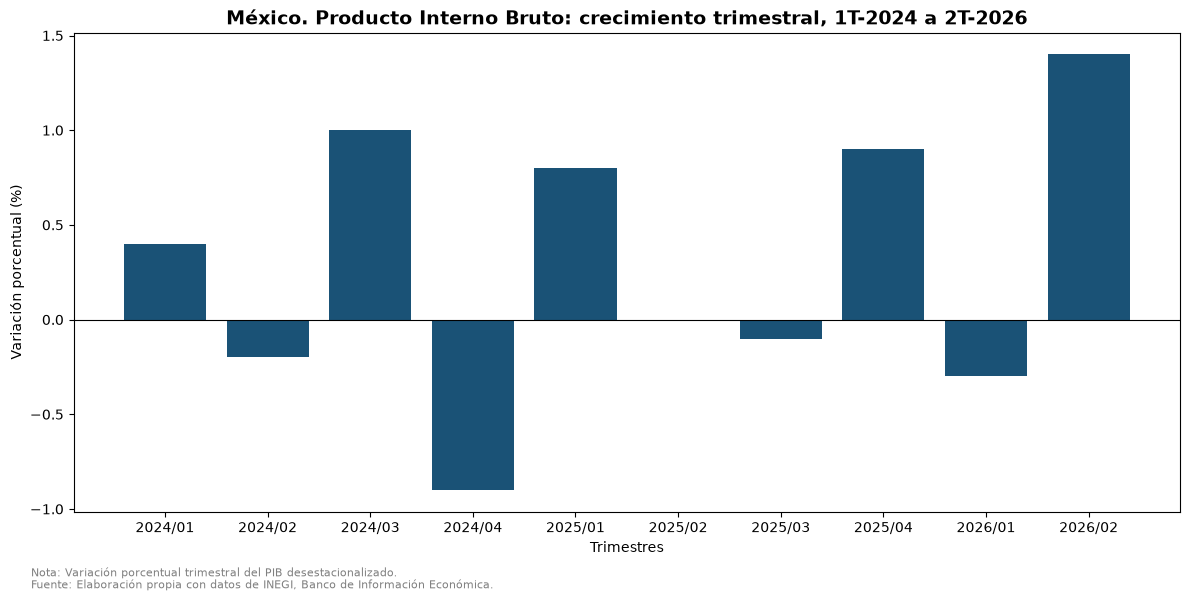

In [12]:
# Gráfica crecimiento de los últimos 10 trimestres (1T-2024 a 2T-2026)

# 1. Crear la figura y la gráfica

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(trimestres['Periodos'], trimestres['Crecimiento_trimestral'], color='#1A5276')

ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('México. Producto Interno Bruto: crecimiento trimestral, 1T-2024 a 2T-2026', fontsize=14, fontweight='bold')

# 2. Configurar los ejes

# 2.1. Eje X

ax.set_xlabel('Trimestres')

# 2.2. Eje Y

ax.set_ylabel('Variación porcentual (%)')

# 3. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Nota: Variación porcentual trimestral del PIB desestacionalizado.', fontsize=8, color='grey', ha='left')
plt.tight_layout(rect=[0, 0.04, 1, 1])

# 4. Guardar gráfica en el directorio figures

plt.savefig('../figures/grafica_05_crecimiento_trimestral_desestacionalizado.png', dpi=150, bbox_inches='tight')

# 5. Mostrar gráfica

plt.show()

El trimestre con mayor crecimiento es el segundo de 2026, con 1.4% respecto al trimestre anterior. El trimestre con la mayor caída es el cuarto de 2024, con -0.9%.

En el periodo analizado, del primer trimestre de 2024 al segundo trimestre de 2026, el crecimiento del PIB es oscilante. Los trimestres alternan entre alzas y bajas, y ninguna tendencia se sostiene por más de un trimestre.

Las variaciones son pequeñas, con excepción del repunte de 1.4% en el segundo trimestre de 2026, que revierte la caída de 0.3% en el primer trimestre de 2026 y supera cualquier otra alza del periodo.

El caso del segundo trimestre de 2025 es particular. Al calcular la variación porcentual y redondear a un decimal, el resultado es 0.0, pero con más decimales corresponde a una caída de 0.02%. Este análisis usa el valor de 0.0, que coincide con el publicado por el INEGI.


## **Conclusiones**

El PIB de México muestra una tendencia creciente de largo plazo, interrumpida por seis contracciones: cinco visibles en la serie original y una sexta, de 1985 a 1986, que solo la serie desestacionalizada permite identificar. Estas caídas se relacionan con crisis internas y choques externos. La más reciente, la pandemia de COVID-19, va seguida de una recuperación rápida, y en 2022 el PIB regresa a niveles similares a los prepandemia.

En los últimos cinco años, el crecimiento anual se desacelera: tras el fuerte repunte de 2021 (6.0%), el PIB crece de forma moderada en 2022 y 2023, y de forma baja en 2024 y 2025 (0.5%, cercano al estancamiento). En el segundo trimestre de 2026, el PIB crece 2.1% respecto al mismo trimestre de 2025 (serie original) y 1.4% respecto al trimestre anterior (serie desestacionalizada). Este último es el mayor avance de los últimos 10 trimestres, que en general alternan entre alzas y bajas pequeñas. Un solo trimestre no basta para hablar de un cambio de tendencia.

En cuanto a las series, ambas muestran la misma tendencia y producen crecimientos anuales muy similares (diferencias de hasta 0.3 puntos porcentuales), porque el efecto estacional tiende a cancelarse al promediar los cuatro trimestres. La serie original sirve para conocer el nivel observado y el crecimiento anual; la desestacionalizada es más adecuada para comparar trimestres consecutivos y delimitar los periodos de contracción y recuperación.